✅ 生成 Figure 1: 价格与情绪走势图
✅ 生成 Figure 2: 买卖压力图


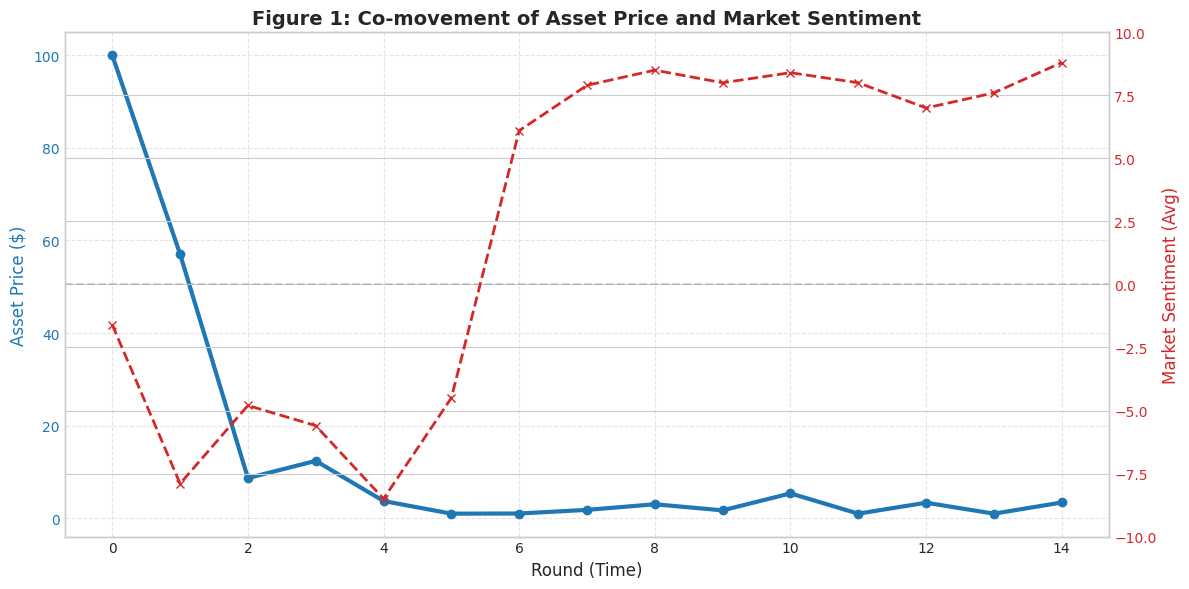

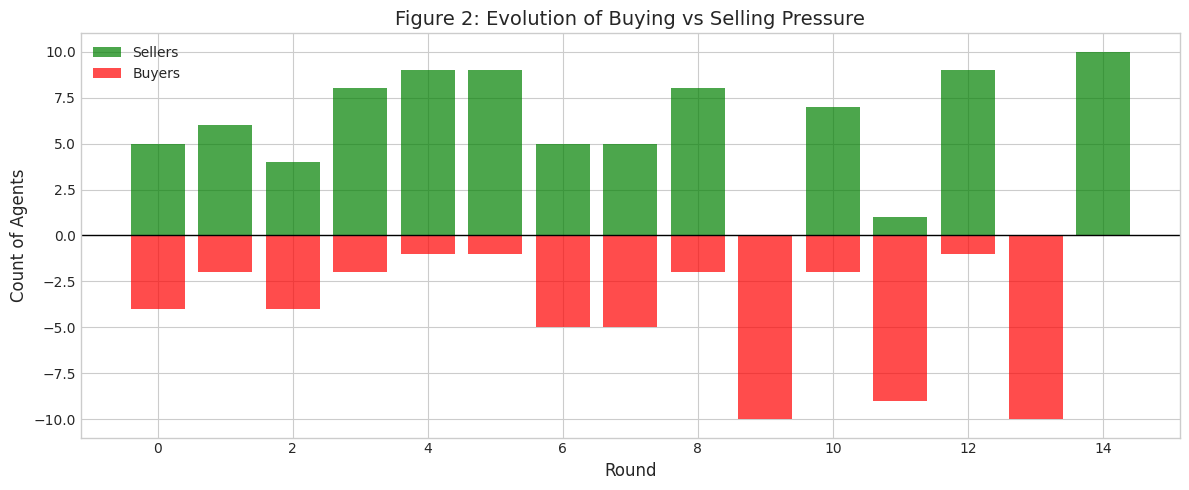

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 加载数据
# ==========================================
# ⚠️ 把这里的名字换成你生成的那个 CSV 文件名
file_path = "simulation_S2_Ambiguity_Rumor.csv" 
df = pd.read_csv(file_path)

# ==========================================
# 2. 数据清洗与聚合
# ==========================================
# 我们需要按“轮数 (Round)”把 10 个 Agent 的数据聚合成市场宏观数据
market_stats = df.groupby('Round').agg({
    'Price': 'last',               # 每一轮结束时的价格
    'Sentiment': 'mean',           # 每一轮的市场平均情绪 (-10 ~ 10)
    'Action': lambda x: x.value_counts().to_dict() # 统计这一轮多少人买/卖
}).reset_index()

# 提取买卖数量
market_stats['Buy_Count'] = market_stats['Action'].apply(lambda x: x.get('BUY', 0))
market_stats['Sell_Count'] = market_stats['Action'].apply(lambda x: x.get('SELL', 0))
market_stats['Hold_Count'] = market_stats['Action'].apply(lambda x: x.get('HOLD', 0))

# ==========================================
# 3. 画图 1: 价格 vs 情绪 (核心图)
# ==========================================
# 设置风格
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(12, 6))

# 绘制价格曲线 (左轴 - 蓝色)
color = 'tab:blue'
ax1.set_xlabel('Round (Time)', fontsize=12)
ax1.set_ylabel('Asset Price ($)', color=color, fontsize=12)
ax1.plot(market_stats['Round'], market_stats['Price'], color=color, linewidth=3, marker='o', label='Price')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, which='major', linestyle='--', alpha=0.5)

# 绘制情绪曲线 (右轴 - 红色)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Market Sentiment (Avg)', color=color, fontsize=12)
# 画一条 0 分界线
ax2.axhline(0, color='gray', linestyle='--', alpha=0.3) 
ax2.plot(market_stats['Round'], market_stats['Sentiment'], color=color, linestyle='--', linewidth=2, marker='x', label='Sentiment')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(-10, 10) # 固定情绪范围

plt.title('Figure 1: Co-movement of Asset Price and Market Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_price_sentiment.png', dpi=300)
print("✅ 生成 Figure 1: 价格与情绪走势图")

# ==========================================
# 4. 画图 2: 买卖压力 (解释图)
# ==========================================
fig, ax = plt.subplots(figsize=(12, 5))

# 堆叠柱状图
rounds = market_stats['Round']
plt.bar(rounds, market_stats['Sell_Count'], color='green', label='Sellers', alpha=0.7)
plt.bar(rounds, -market_stats['Buy_Count'], color='red', label='Buyers', alpha=0.7) # 买家画在下方

plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Round', fontsize=12)
plt.ylabel('Count of Agents', fontsize=12)
plt.title('Figure 2: Evolution of Buying vs Selling Pressure', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('fig2_buy_sell_pressure.png', dpi=300)
print("✅ 生成 Figure 2: 买卖压力图")

plt.show()

✅ 滑动相关性图表已生成。

=== Phase 1 (Crash) Regression Results ===
R-squared: 0.2400
Coef (Sentiment): 7.7751
P-value: 0.3239

=== Phase 2 (Delusion) Regression Results ===
R-squared: 0.2148
Coef (Sentiment): 0.8335
P-value: 0.2089


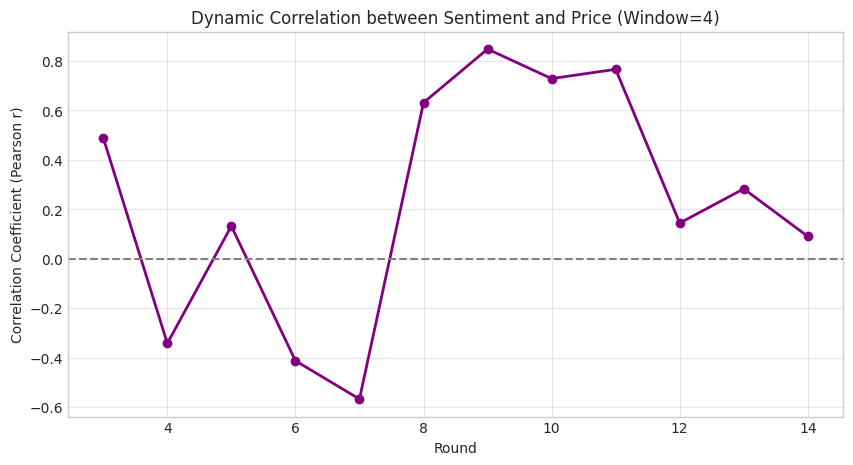

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

# ==========================================
# 1. 准备数据
# ==========================================
file_path = "simulation_S2_Ambiguity_Rumor.csv"  # 你的文件名
df = pd.read_csv(file_path)

# 聚合每一轮的市场均值
market_stats = df.groupby('Round').agg({
    'Price': 'last',
    'Sentiment': 'mean'
}).reset_index()

# ==========================================
# 2. 动态分析：滑动相关系数 (Rolling Correlation)
# ==========================================
# 窗口设为 4 (因为总共15轮，4轮足以捕捉短期变化)
window_size = 4
market_stats['Rolling_Corr'] = market_stats['Sentiment'].rolling(window=window_size).corr(market_stats['Price'])

# 画图：滑动相关性曲线
plt.figure(figsize=(10, 5))
plt.plot(market_stats['Round'], market_stats['Rolling_Corr'], color='purple', linewidth=2, marker='o')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Dynamic Correlation between Sentiment and Price (Window=4)')
plt.ylabel('Correlation Coefficient (Pearson r)')
plt.xlabel('Round')
plt.grid(True, alpha=0.5)
plt.savefig('stat_rolling_corr.png')
print("✅ 滑动相关性图表已生成。")

# ==========================================
# 3. 静态验证：分段回归 (Segmented Regression)
# ==========================================
# 根据之前的观察，断点 (Break Point) 设在 Round 5
break_point = 5

phase1 = market_stats[market_stats['Round'] <= break_point]
phase2 = market_stats[market_stats['Round'] > break_point]

def run_regression(data, phase_name):
    X = data['Sentiment']
    Y = data['Price']
    X = sm.add_constant(X) # 加截距项
    
    model = sm.OLS(Y, X).fit()
    
    print(f"\n=== {phase_name} Regression Results ===")
    print(f"R-squared: {model.rsquared:.4f}")
    print(f"Coef (Sentiment): {model.params['Sentiment']:.4f}")
    print(f"P-value: {model.pvalues['Sentiment']:.4f}")
    return model

# 运行两段回归
model1 = run_regression(phase1, "Phase 1 (Crash)")
model2 = run_regression(phase2, "Phase 2 (Delusion)")

✅ 生成 Figure 1: 价格与情绪走势图
✅ 生成 Figure 2: 买卖压力图


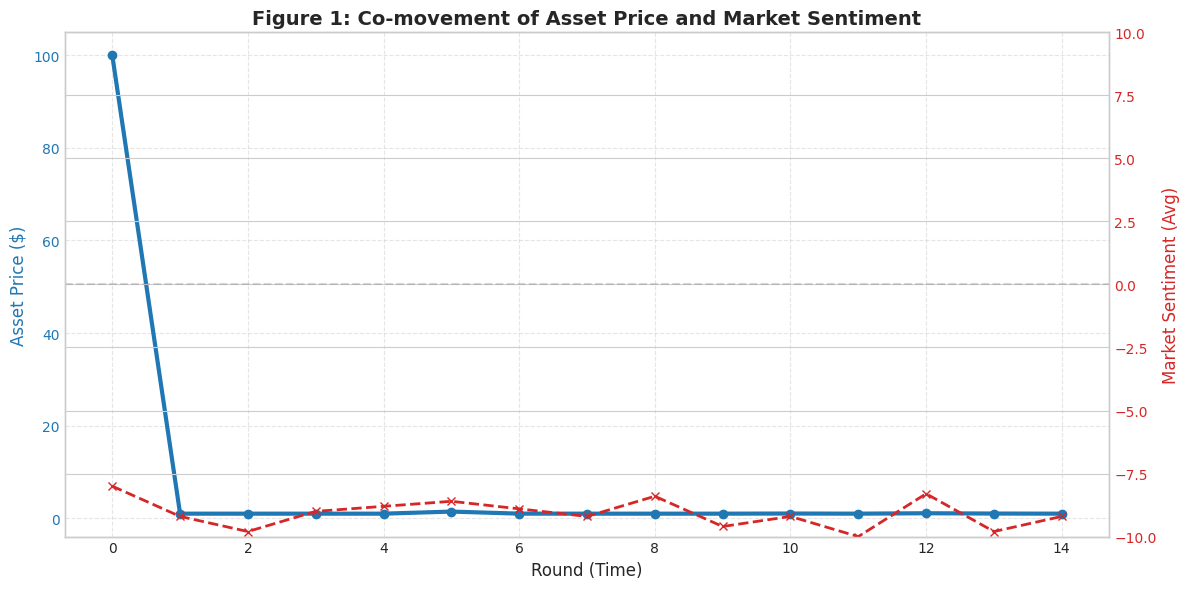

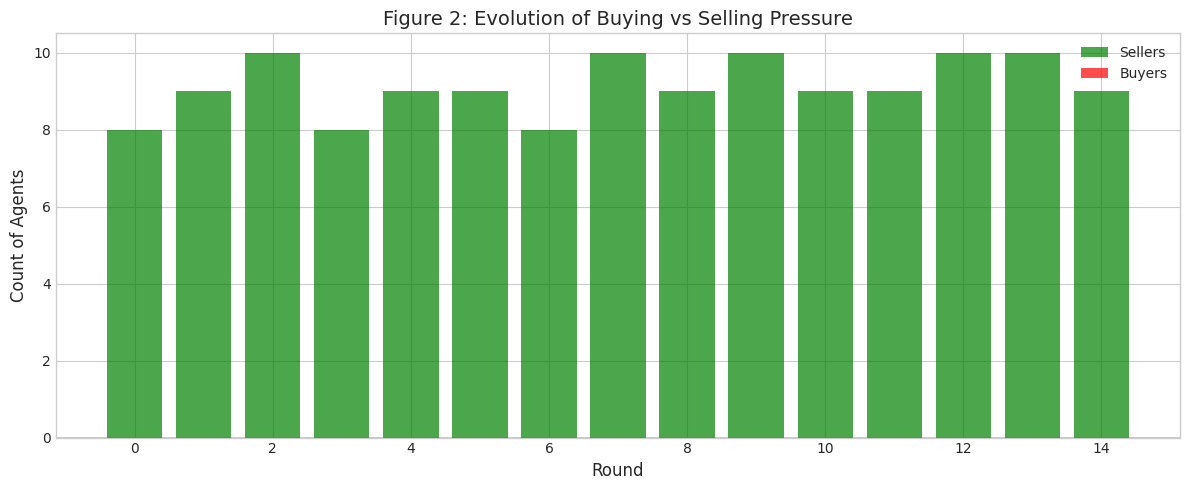

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 加载数据
# ==========================================
# ⚠️ 把这里的名字换成你生成的那个 CSV 文件名
file_path = "simulation_S5_Failed_Correction.csv" 
df = pd.read_csv(file_path)

# ==========================================
# 2. 数据清洗与聚合
# ==========================================
# 我们需要按“轮数 (Round)”把 10 个 Agent 的数据聚合成市场宏观数据
market_stats = df.groupby('Round').agg({
    'Price': 'last',               # 每一轮结束时的价格
    'Sentiment': 'mean',           # 每一轮的市场平均情绪 (-10 ~ 10)
    'Action': lambda x: x.value_counts().to_dict() # 统计这一轮多少人买/卖
}).reset_index()

# 提取买卖数量
market_stats['Buy_Count'] = market_stats['Action'].apply(lambda x: x.get('BUY', 0))
market_stats['Sell_Count'] = market_stats['Action'].apply(lambda x: x.get('SELL', 0))
market_stats['Hold_Count'] = market_stats['Action'].apply(lambda x: x.get('HOLD', 0))

# ==========================================
# 3. 画图 1: 价格 vs 情绪 (核心图)
# ==========================================
# 设置风格
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(12, 6))

# 绘制价格曲线 (左轴 - 蓝色)
color = 'tab:blue'
ax1.set_xlabel('Round (Time)', fontsize=12)
ax1.set_ylabel('Asset Price ($)', color=color, fontsize=12)
ax1.plot(market_stats['Round'], market_stats['Price'], color=color, linewidth=3, marker='o', label='Price')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, which='major', linestyle='--', alpha=0.5)

# 绘制情绪曲线 (右轴 - 红色)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Market Sentiment (Avg)', color=color, fontsize=12)
# 画一条 0 分界线
ax2.axhline(0, color='gray', linestyle='--', alpha=0.3) 
ax2.plot(market_stats['Round'], market_stats['Sentiment'], color=color, linestyle='--', linewidth=2, marker='x', label='Sentiment')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(-10, 10) # 固定情绪范围

plt.title('Figure 1: Co-movement of Asset Price and Market Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('S5_fig1_price_sentiment.png', dpi=300)
print("✅ 生成 Figure 1: 价格与情绪走势图")

# ==========================================
# 4. 画图 2: 买卖压力 (解释图)
# ==========================================
fig, ax = plt.subplots(figsize=(12, 5))

# 堆叠柱状图
rounds = market_stats['Round']
plt.bar(rounds, market_stats['Sell_Count'], color='green', label='Sellers', alpha=0.7)
plt.bar(rounds, -market_stats['Buy_Count'], color='red', label='Buyers', alpha=0.7) # 买家画在下方

plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Round', fontsize=12)
plt.ylabel('Count of Agents', fontsize=12)
plt.title('Figure 2: Evolution of Buying vs Selling Pressure', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('S5_fig2_buy_sell_pressure.png', dpi=300)
print("✅ 生成 Figure 2: 买卖压力图")

plt.show()

✅ 滑动相关性图表已生成。

=== Phase 1 (Crash) Regression Results ===
R-squared: 0.1869
Coef (Sentiment): 71.0970
P-value: 0.3919

=== Phase 2 (Delusion) Regression Results ===
R-squared: 0.0062
Coef (Sentiment): -21.4331
P-value: 0.8403


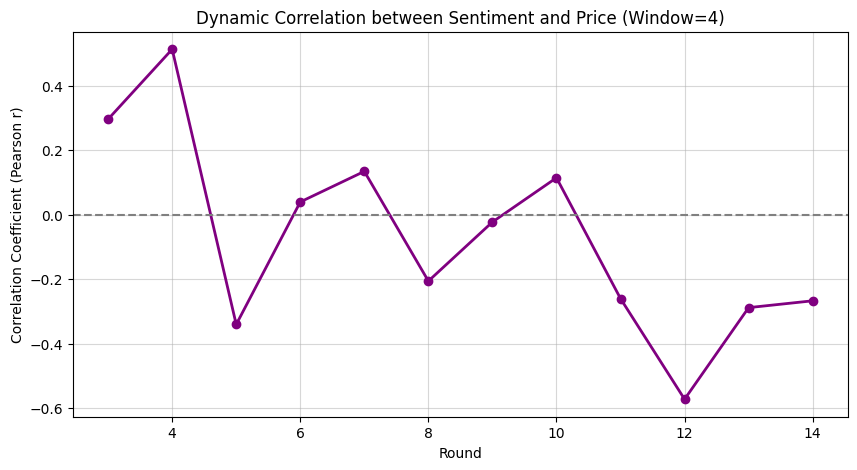

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

# ==========================================
# 1. 准备数据
# ==========================================
file_path = "simulation_S3_Positive_Hype.csv"  # 你的文件名
df = pd.read_csv(file_path)

# 聚合每一轮的市场均值
market_stats = df.groupby('Round').agg({
    'Price': 'last',
    'Sentiment': 'mean'
}).reset_index()

# ==========================================
# 2. 动态分析：滑动相关系数 (Rolling Correlation)
# ==========================================
# 窗口设为 4 (因为总共15轮，4轮足以捕捉短期变化)
window_size = 4
market_stats['Rolling_Corr'] = market_stats['Sentiment'].rolling(window=window_size).corr(market_stats['Price'])

# 画图：滑动相关性曲线
plt.figure(figsize=(10, 5))
plt.plot(market_stats['Round'], market_stats['Rolling_Corr'], color='purple', linewidth=2, marker='o')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Dynamic Correlation between Sentiment and Price (Window=4)')
plt.ylabel('Correlation Coefficient (Pearson r)')
plt.xlabel('Round')
plt.grid(True, alpha=0.5)
plt.savefig('stat_rolling_corr.png')
print("✅ 滑动相关性图表已生成。")

# ==========================================
# 3. 静态验证：分段回归 (Segmented Regression)
# ==========================================
# 根据之前的观察，断点 (Break Point) 设在 Round 5
break_point = 5

phase1 = market_stats[market_stats['Round'] <= break_point]
phase2 = market_stats[market_stats['Round'] > break_point]

def run_regression(data, phase_name):
    X = data['Sentiment']
    Y = data['Price']
    X = sm.add_constant(X) # 加截距项
    
    model = sm.OLS(Y, X).fit()
    
    print(f"\n=== {phase_name} Regression Results ===")
    print(f"R-squared: {model.rsquared:.4f}")
    print(f"Coef (Sentiment): {model.params['Sentiment']:.4f}")
    print(f"P-value: {model.pvalues['Sentiment']:.4f}")
    return model

# 运行两段回归
model1 = run_regression(phase1, "Phase 1 (Crash)")
model2 = run_regression(phase2, "Phase 2 (Delusion)")